Importy

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import glob
import itertools
import copy

Wspólne klasy i funkcje sieci

In [2]:
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

def train_greybox_model(model, dataloader, epochs=2000, patience=80, min_delta=1e-6):
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    # Zmiana gamma na 0.90
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.90)
    # Zmiana MSE na MAE (L1Loss)
    criterion = nn.L1Loss()
    
    best_loss = float('inf')
    patience_counter = 0    
    best_model_weights = copy.deepcopy(model.state_dict())
    
    model.train()
    print(f"Rozpoczynam trening (Maksymalnie {epochs} epok, Cierpliwość: {patience})...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for u_seq, y_true_seq in dataloader:
            x_init = torch.zeros(u_seq.size(0), model.num_states)
            optimizer.zero_grad()
            y_pred_seq = model(u_seq, x_init)
            loss = criterion(y_pred_seq.view_as(y_true_seq), y_true_seq)
            
            loss.backward()
            
            # ====================================================
            # NOWOŚĆ: Obcinanie gradientów (zabezpieczenie przed eksplozją)
            # ====================================================
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1}/{epochs} | Strata MAE: {avg_loss:.6f}")
            
        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss               
            patience_counter = 0               
            best_model_weights = copy.deepcopy(model.state_dict()) 
        else:
            patience_counter += 1              
            
        if patience_counter >= patience:
            print(f"\n[!] EARLY STOPPING: Przerwano trening w epoce {epoch+1}!")
            print(f"Brak poprawy o minimum {min_delta} od {patience} epok.")
            break 
            
    model.load_state_dict(best_model_weights)
    print(f"Trening zakończony. Załadowano najlepsze wagi ze stratą MAE: {best_loss:.6f}\n")
    return model

def create_sequences(inputs, targets, seq_len=600):
    xs, ys = [], []
    for i in range(0, len(inputs) - seq_len + 1, seq_len):
        xs.append(inputs[i : i + seq_len])
        ys.append(targets[i : i + seq_len])
    return np.array(xs), np.array(ys)

# ==========================================
# ULEPSZONA FUNKCJA WALIDACJI Z FILTREM REZIDUUM I "STREFĄ CISZY" (Burn-in)
# ==========================================
def validate_and_plot(model, scaler_u, scaler_y, input_cols, target_cols, file_path, title_prefix, alpha=0.05, threshold=None, burn_in=50):
    df_test = pd.read_csv(file_path)
    X_test_tensor = torch.tensor(scaler_u.transform(df_test[input_cols].values), dtype=torch.float32).unsqueeze(0)
    Y_test_tensor = torch.tensor(scaler_y.transform(df_test[target_cols].values), dtype=torch.float32).unsqueeze(0)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor, torch.zeros(1, model.num_states))
        
    y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
    y_true_real = scaler_y.inverse_transform(Y_test_tensor[0].cpu().numpy().reshape(-1, 1))
    czas = np.arange(len(y_true_real)) * 0.05
    
    e_raw = np.abs(y_true_real - y_pred_real) 
    e_filtered = np.zeros_like(e_raw)         
    e_filtered[0] = e_raw[0]                  
    
    for i in range(1, len(e_raw)):
        e_filtered[i] = alpha * e_raw[i] + (1 - alpha) * e_filtered[i-1]
        
    if burn_in > 0:
        e_raw[:burn_in] = 0.0
        e_filtered[:burn_in] = 0.0
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    ax1.plot(czas, y_true_real, label='Prawda (Czujnik)', color='black', alpha=0.7)
    ax1.plot(czas, y_pred_real, label='Symulacja (AI)', color='red', linestyle='--', alpha=0.9)
    ax1.set_title(f'{title_prefix} | Plik: {file_path.split("/")[-1]}', fontsize=12)
    ax1.set_ylabel('Wartość fizyczna (np. Pa)')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    ax2.plot(czas, e_raw, label='Surowe Reziduum (Szum)', color='gray', alpha=0.4)
    ax2.plot(czas, e_filtered, label=f'Przefiltrowane Reziduum (alpha={alpha})', color='darkred', linewidth=2)
    
    if threshold is not None:
        ax2.axhline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Próg Detekcji ({threshold})')
        
    ax2.set_title('Sygnał Diagnostyczny (Reziduum)', fontsize=12)
    ax2.set_xlabel('Czas [s]')
    ax2.set_ylabel('Błąd predykcji')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Średni błąd bezwzględny (MAE po rozgrzewce): {np.mean(e_raw[burn_in:]):.4f}")
    print(f"Maksymalny błąd przefiltrowany (po rozgrzewce): {np.max(e_filtered[burn_in:]):.4f}")

MSO_10 - Intercooler

In [3]:
class GreyBoxSystem_MSO10(nn.Module):
    def __init__(self, T_sample=0.05):
        super(GreyBoxSystem_MSO10, self).__init__()
        self.T, self.num_states, self.num_inputs = T_sample, 1, 4
        total_feat = self.num_states + self.num_inputs
        self.g_func, self.h_func = SubNetwork(total_feat, 1), SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

u_cols_10 = ['air_mass_flow', 'intercooler_temperature', 'intake_manifold_pressure', 'throttle_position']
y_cols_10 = ['Intercooler_pressure']

# Upewnij się, że ścieżki są poprawne dla Twojego środowiska
df_train_wltp_1 = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\Inzynierka\Fault_Diagnosis_Toolbox\data\wltp_NF.csv")
df_train_wltp_2 = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\Inzynierka\Fault_Diagnosis_Toolbox\data\wltp_NF_2.csv")
df_train_ftp = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\Inzynierka\Fault_Diagnosis_Toolbox\data\ftp75city2_NF.csv")
df_wltp_leackage_0 = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_iml_4mm.csv") 
df_wltp_leackage_1 = pd.read_csv(r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_iml_6mm.csv")

# Standardowe łączenie plików (bez duplikowania FTP)
df_train_nf = pd.concat([df_train_ftp, df_train_wltp_1, df_train_wltp_2, df_wltp_leackage_0, df_wltp_leackage_1], ignore_index=True)

scaler_u10, scaler_y10 = MinMaxScaler(), MinMaxScaler()
u10_norm = scaler_u10.fit_transform(df_train_nf[u_cols_10].values)
y10_norm = scaler_y10.fit_transform(df_train_nf[y_cols_10].values)

X_seq10, Y_seq10 = create_sequences(u10_norm, y10_norm, seq_len=100)
loader10 = DataLoader(TensorDataset(torch.tensor(X_seq10, dtype=torch.float32), torch.tensor(Y_seq10, dtype=torch.float32)), batch_size=16, shuffle=True)

# --- TRENOWANIE ---
#Odkomentuj poniższe linie, gdy chcesz wytrenować model na nowo
#model10 = GreyBoxSystem_MSO10()
#model10 = train_greybox_model(model10, loader10, epochs=2000)

#torch.save(model10.state_dict(), 'szara_skrzynka_mso10_wagi_zmiejszone.pth')
#joblib.dump(scaler_u10, 'scaler_u_mso10_zmniejszone.pkl')
#joblib.dump(scaler_y10, 'scaler_y_mso10_zmniejszone.pkl')

print("Komórka MSO 10 gotowa!")

Komórka MSO 10 gotowa!


Model MSO 10 i skalery zostały pomyślnie wczytane z dysku!


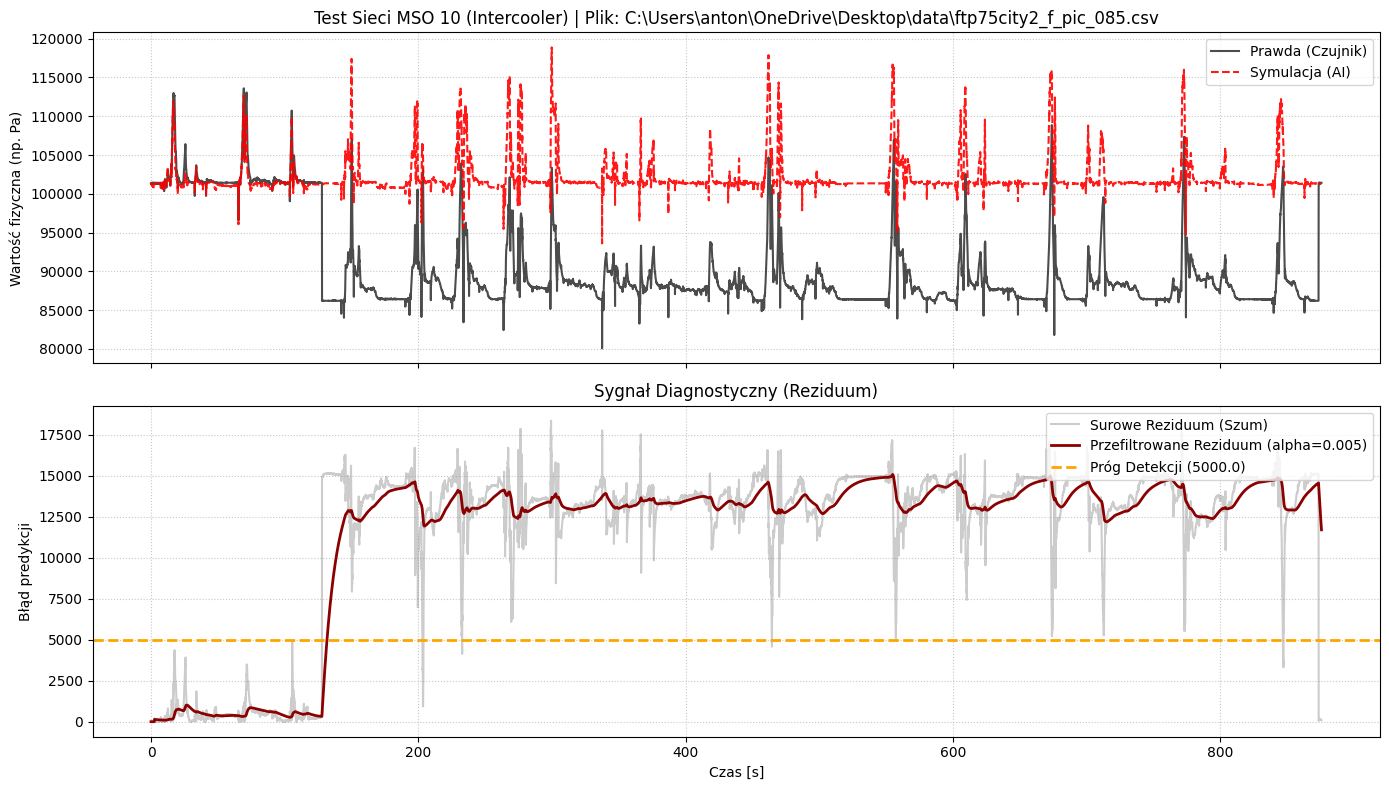

Średni błąd bezwzględny (MAE po rozgrzewce): 11700.0557
Maksymalny błąd przefiltrowany (po rozgrzewce): 15088.9619


In [4]:
model10 = GreyBoxSystem_MSO10(T_sample=0.05)

# 2. Wczytanie wag i skalerów z dysku (Upewnij się, że pliki istnieją! Jeżeli nie, odpal wpierw trening wyżej)
model10.load_state_dict(torch.load('szara_skrzynka_mso10_wagi_zmiejszone.pth'))
model10.eval() # Ustawienie modelu w tryb predykcji
scaler_u10 = joblib.load('scaler_u_mso10_zmniejszone.pkl')
scaler_y10 = joblib.load('scaler_y_mso10_zmniejszone.pkl')

print("Model MSO 10 i skalery zostały pomyślnie wczytane z dysku!")

# 3. Uruchomienie testu z filtrem EMA i Strefą Ciszy!
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pic_085.csv" # Podmień na swój plik testowy z usterką

# Parametry alpha, threshold i burn_in możesz tu swobodnie modyfikować:
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

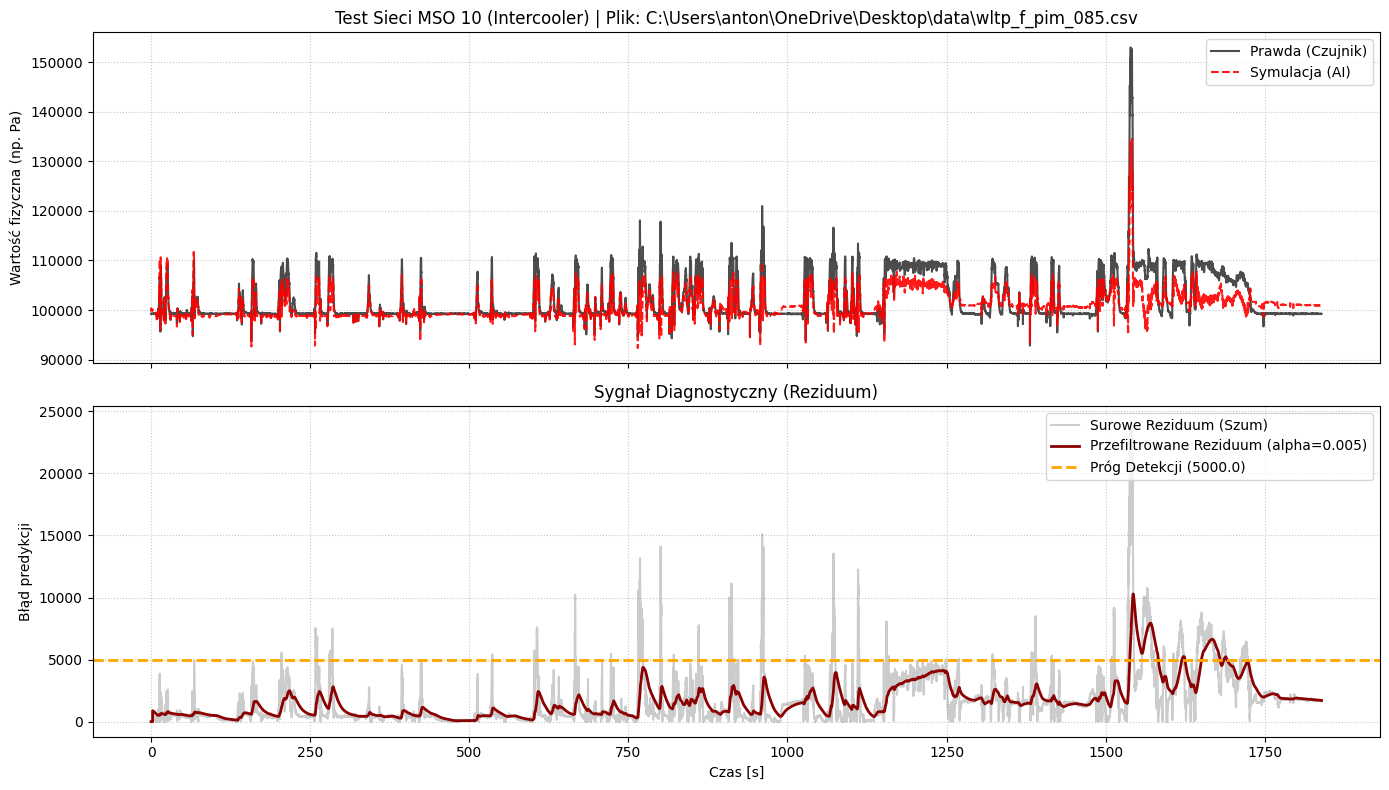

Średni błąd bezwzględny (MAE po rozgrzewce): 1756.5282
Maksymalny błąd przefiltrowany (po rozgrzewce): 10297.7529


In [7]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_pim_085.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

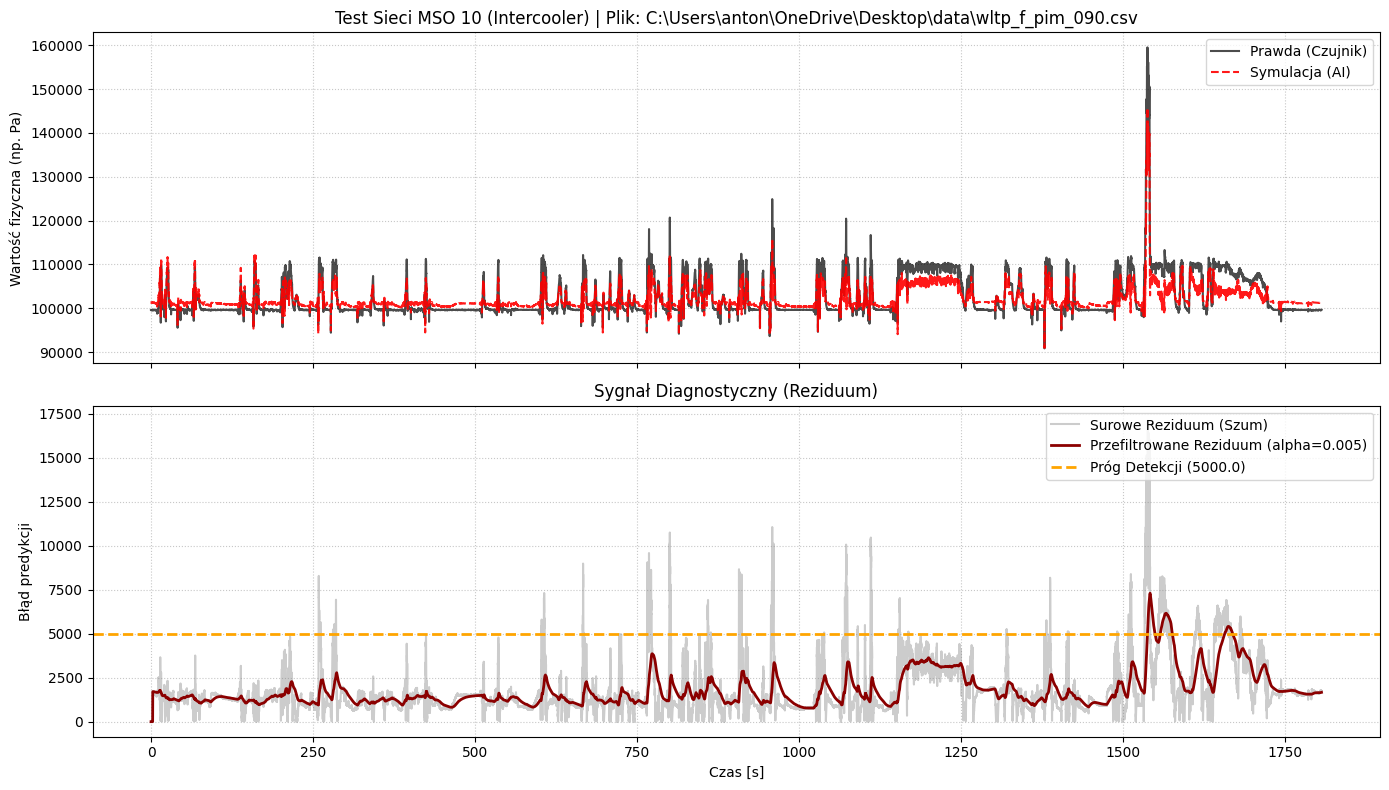

Średni błąd bezwzględny (MAE po rozgrzewce): 1821.5420
Maksymalny błąd przefiltrowany (po rozgrzewce): 7296.6245


In [8]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_pim_090.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

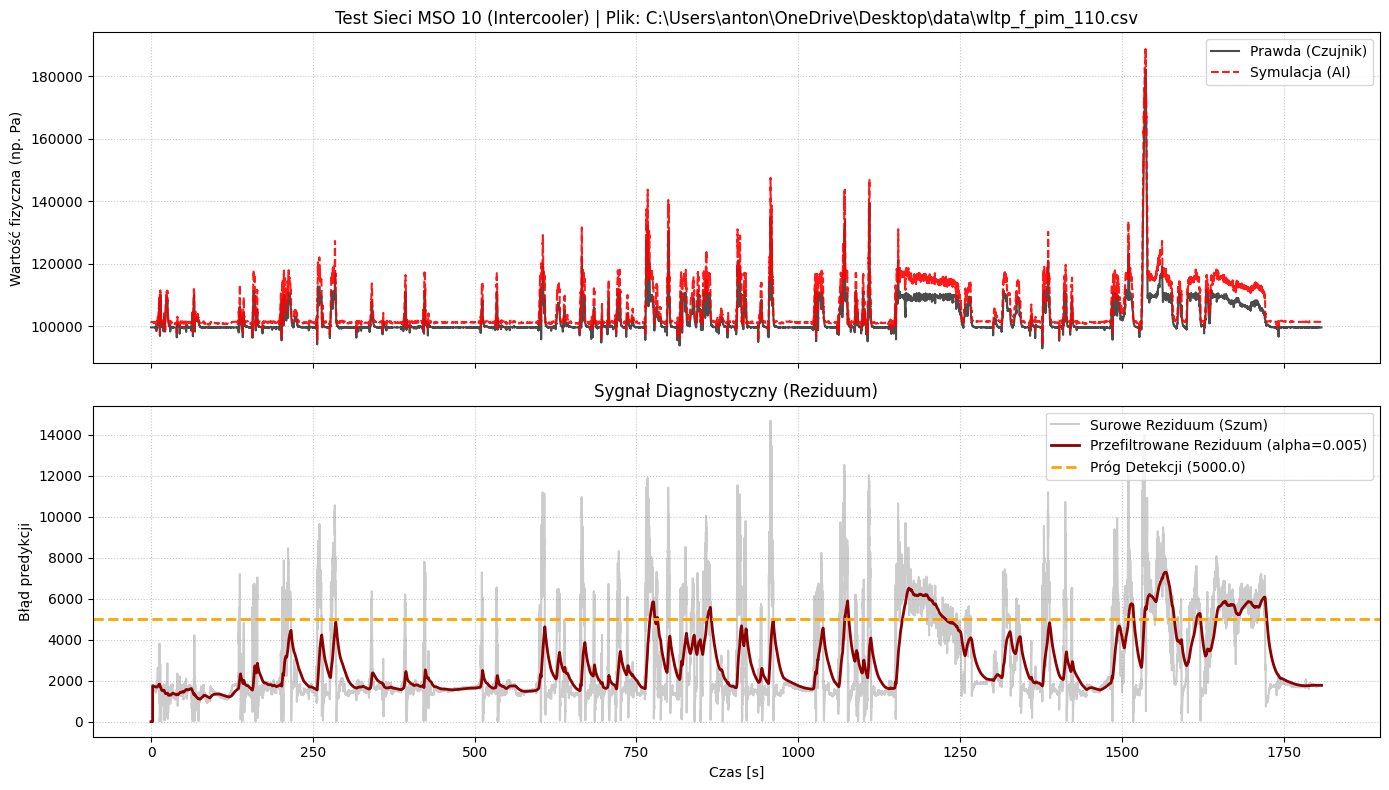

Średni błąd bezwzględny (MAE po rozgrzewce): 2859.1345
Maksymalny błąd przefiltrowany (po rozgrzewce): 7296.7334


In [9]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_pim_110.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

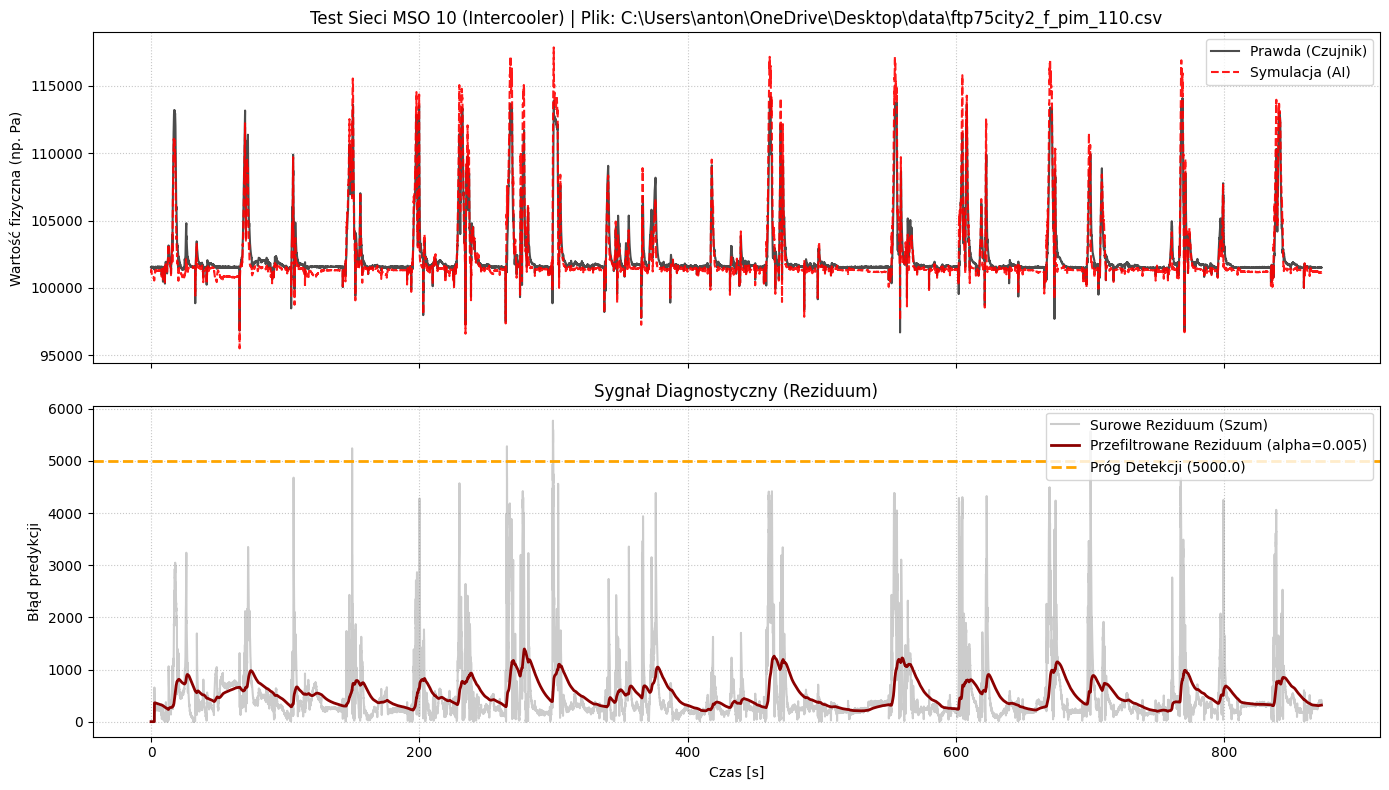

Średni błąd bezwzględny (MAE po rozgrzewce): 522.4276
Maksymalny błąd przefiltrowany (po rozgrzewce): 1394.3530


In [10]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pim_110.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

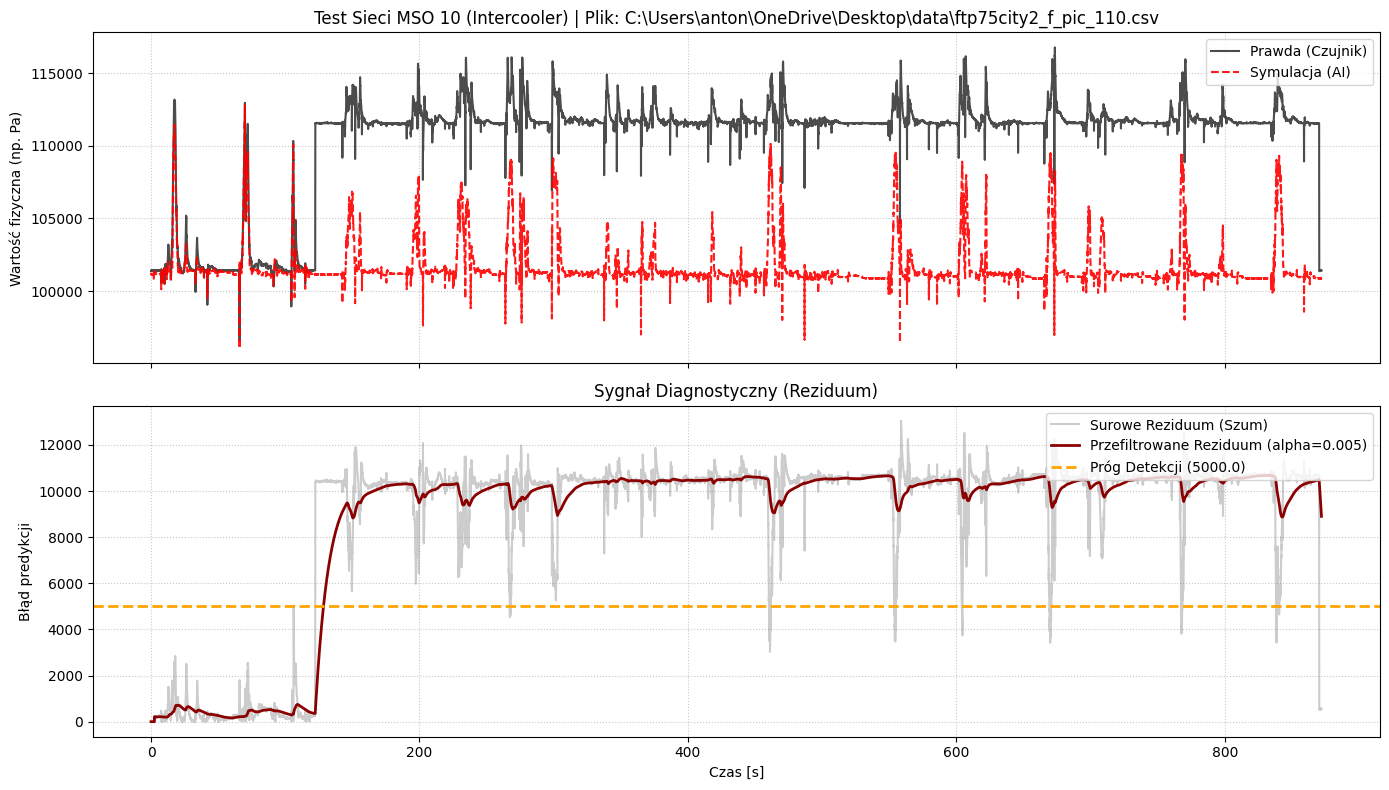

Średni błąd bezwzględny (MAE po rozgrzewce): 8886.0791
Maksymalny błąd przefiltrowany (po rozgrzewce): 10678.5098


In [11]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pic_110.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

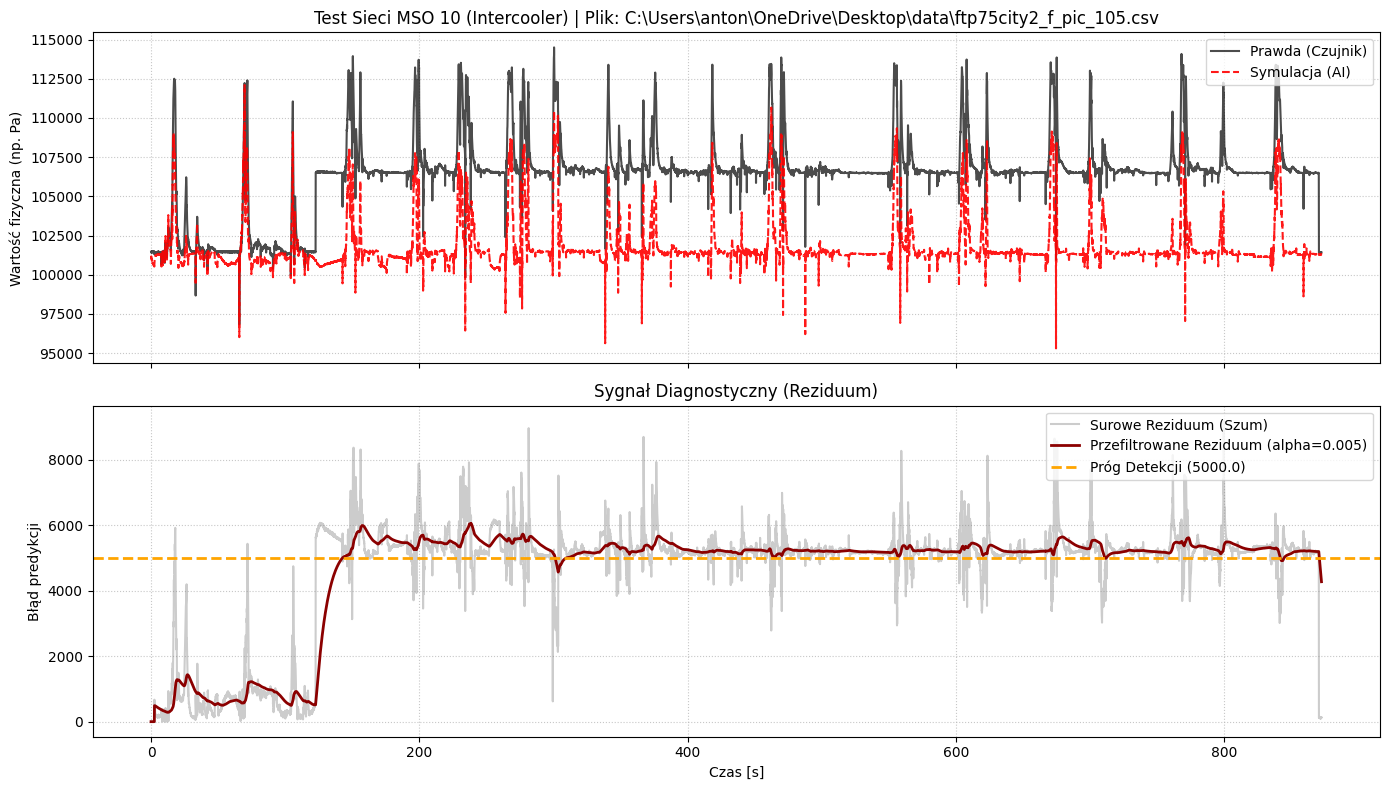

Średni błąd bezwzględny (MAE po rozgrzewce): 4684.0493
Maksymalny błąd przefiltrowany (po rozgrzewce): 6055.6934


In [16]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pic_105.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=5000.0, burn_in=50)

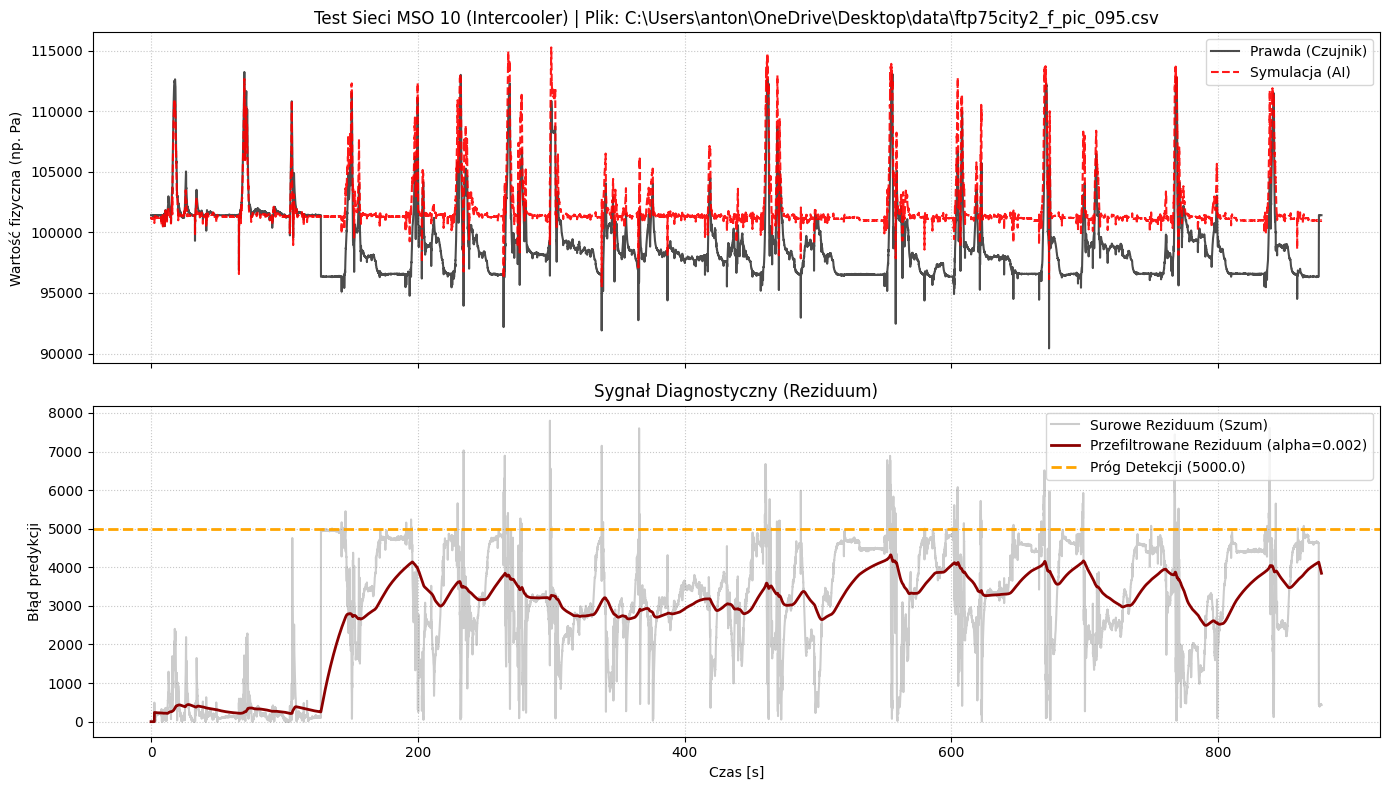

Średni błąd bezwzględny (MAE po rozgrzewce): 2978.7896
Maksymalny błąd przefiltrowany (po rozgrzewce): 4323.0078


In [17]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pic_095.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.002, threshold=5000.0, burn_in=50)

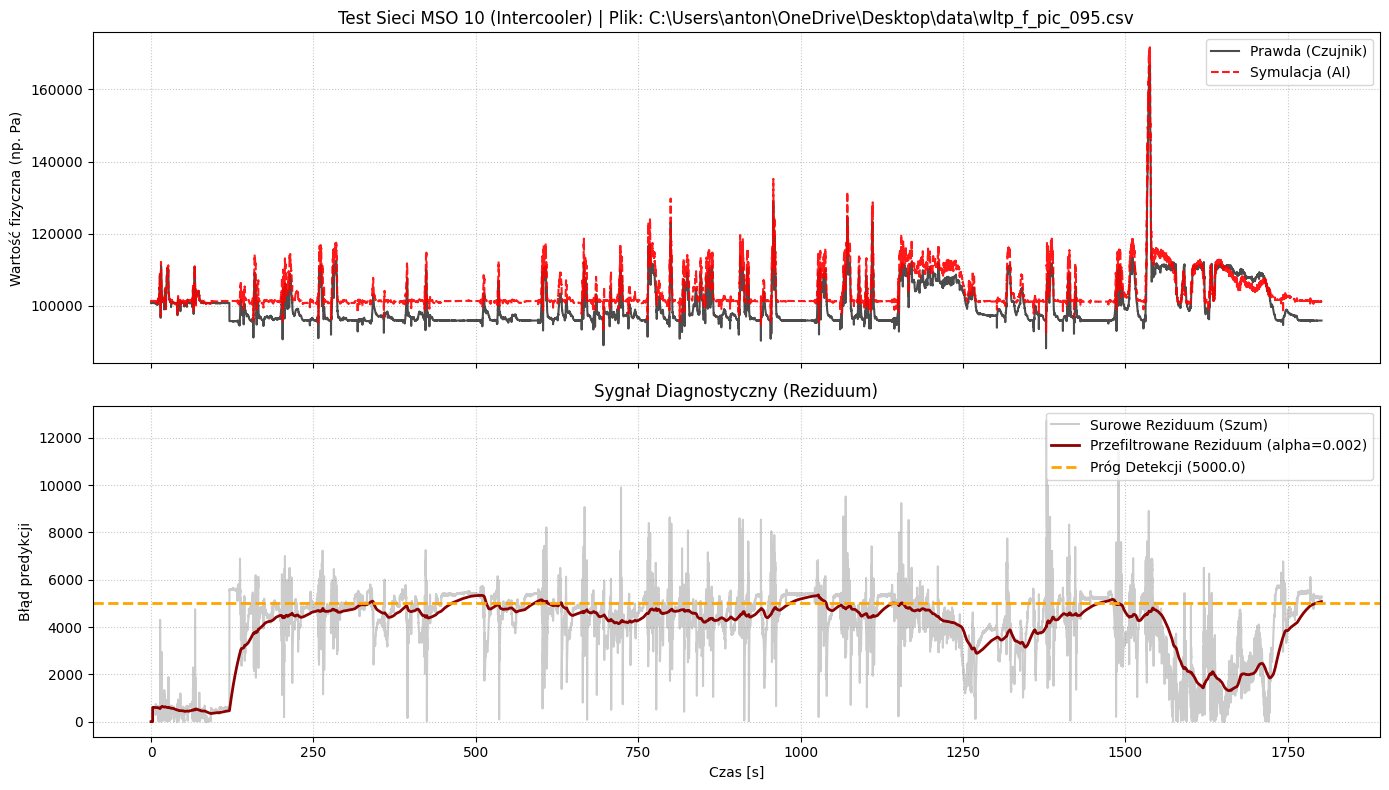

Średni błąd bezwzględny (MAE po rozgrzewce): 4063.5093
Maksymalny błąd przefiltrowany (po rozgrzewce): 5358.2207


In [18]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_pic_095.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.002, threshold=5000.0, burn_in=50)

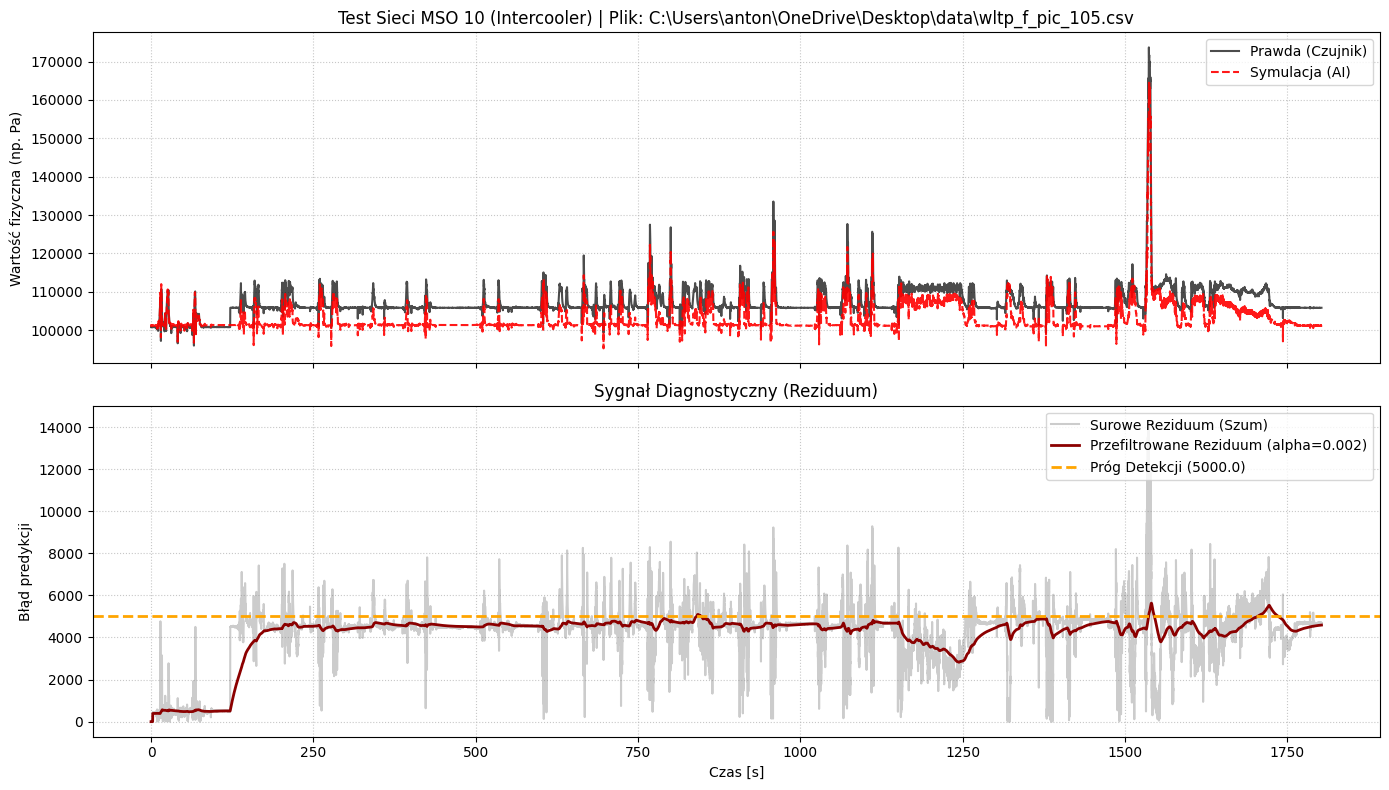

Średni błąd bezwzględny (MAE po rozgrzewce): 4232.3892
Maksymalny błąd przefiltrowany (po rozgrzewce): 5633.1177


In [19]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_pic_105.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.002, threshold=5000.0, burn_in=50)

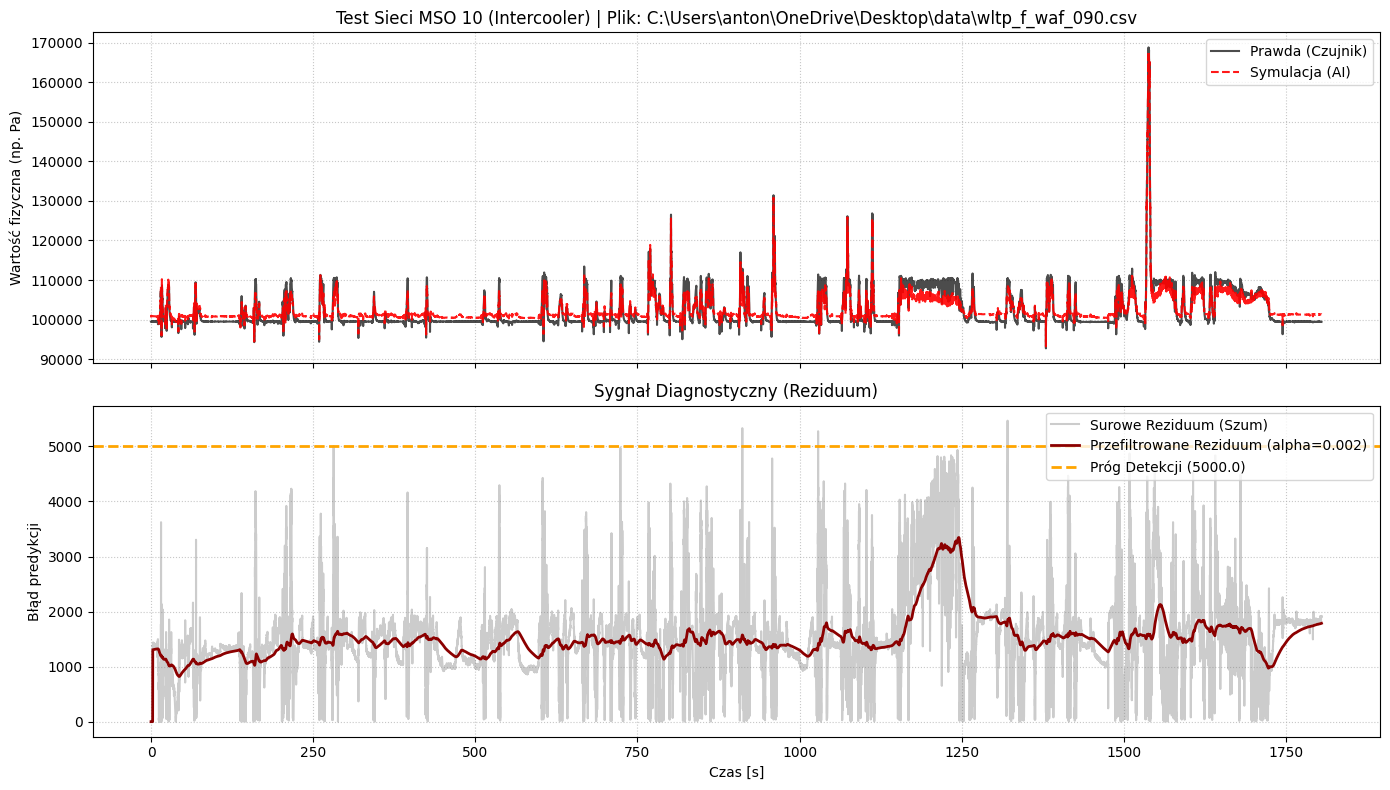

Średni błąd bezwzględny (MAE po rozgrzewce): 1521.1697
Maksymalny błąd przefiltrowany (po rozgrzewce): 3346.8494


In [23]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_waf_090.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.002, threshold=5000.0, burn_in=50)

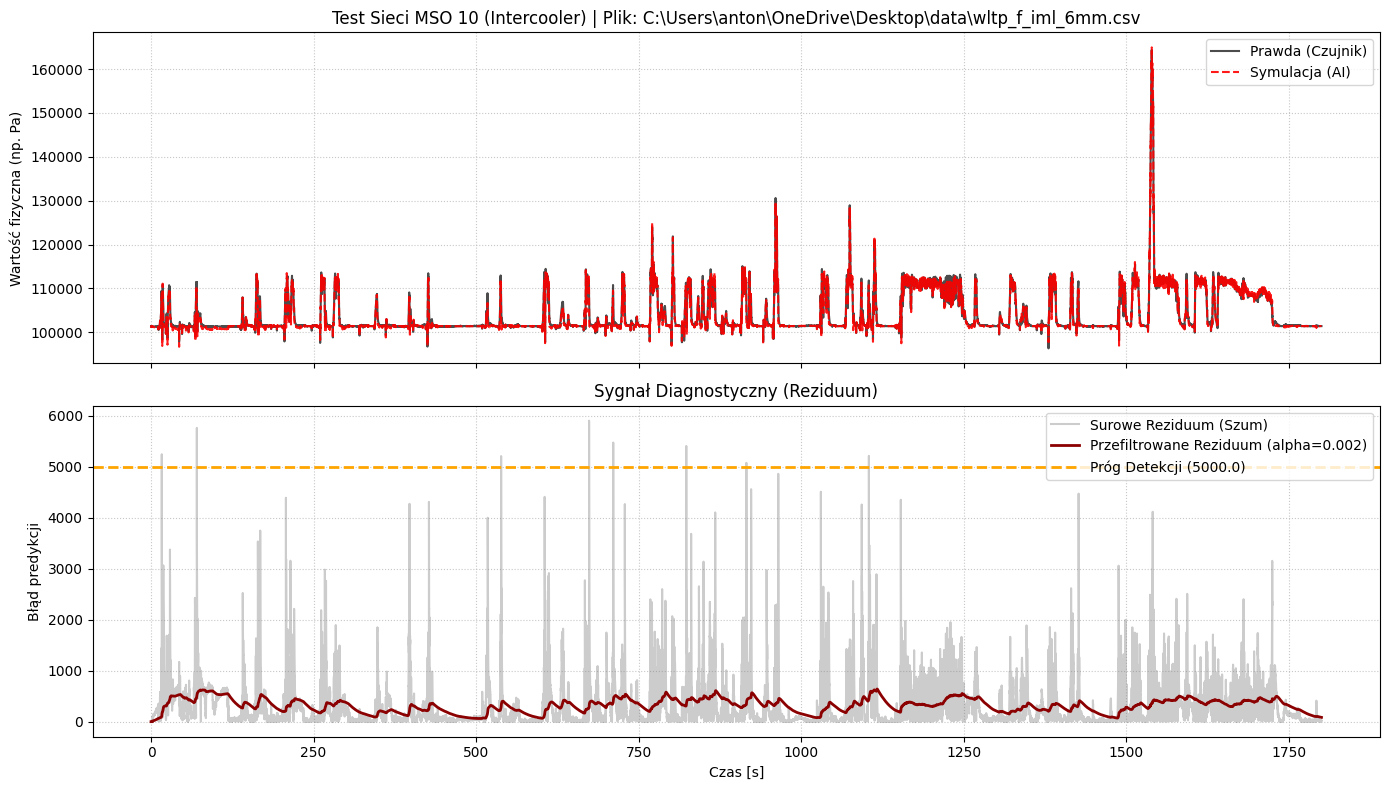

Średni błąd bezwzględny (MAE po rozgrzewce): 320.6828
Maksymalny błąd przefiltrowany (po rozgrzewce): 640.6120


In [24]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\wltp_f_iml_6mm.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.002, threshold=5000.0, burn_in=50)

In [ ]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pim_090.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.002, threshold=5000.0, burn_in=50)

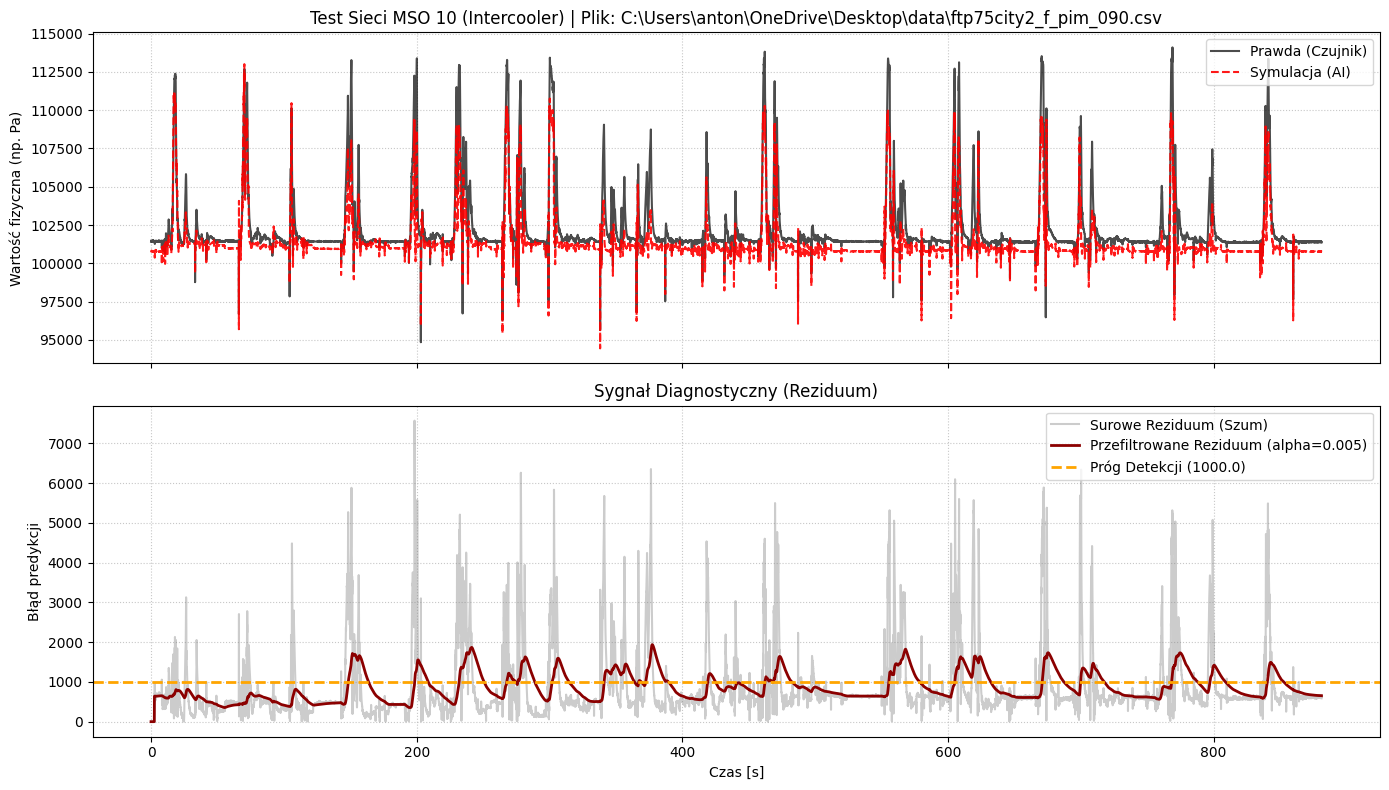

Średni błąd bezwzględny (MAE po rozgrzewce): 877.5733
Maksymalny błąd przefiltrowany (po rozgrzewce): 1936.6488


In [5]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_pim_090.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=1000.0, burn_in=50)

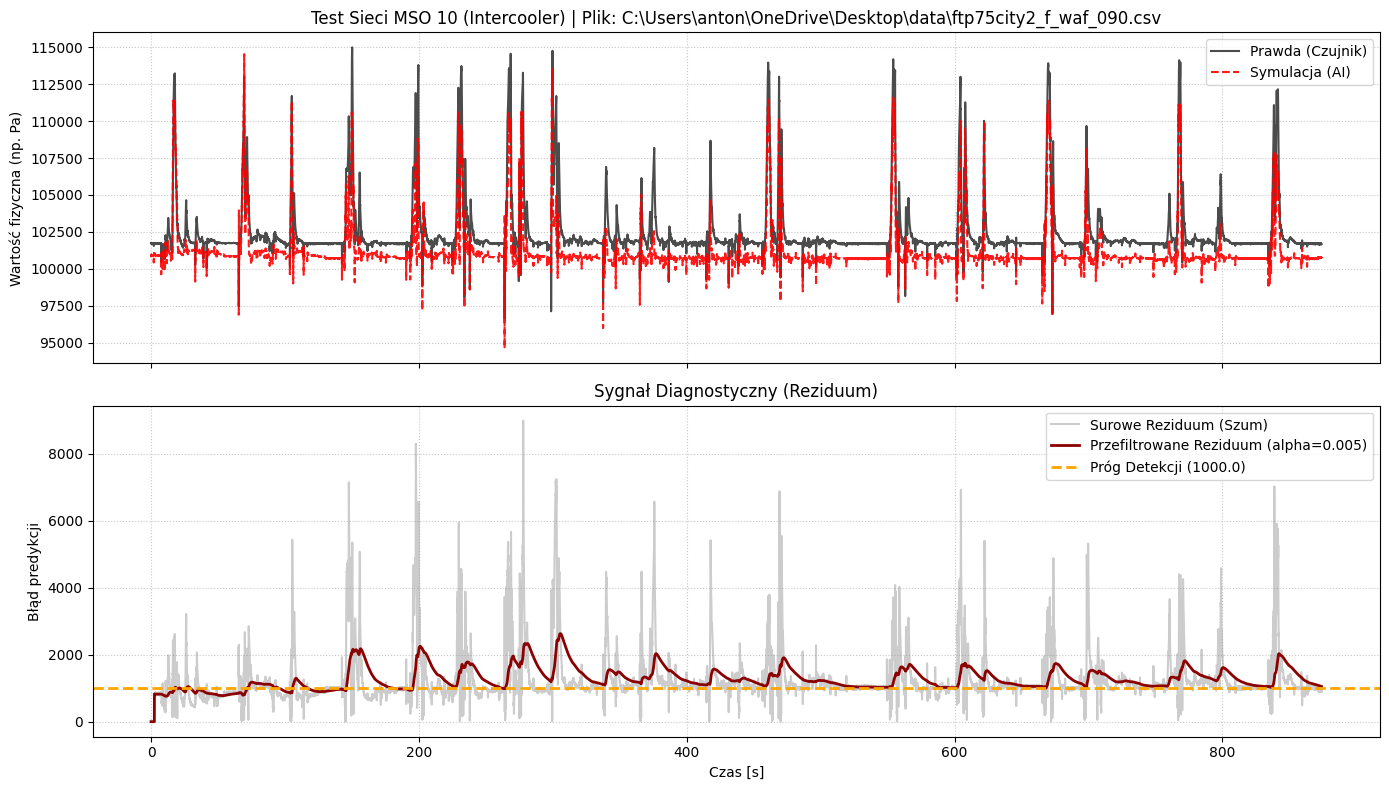

Średni błąd bezwzględny (MAE po rozgrzewce): 1286.7177
Maksymalny błąd przefiltrowany (po rozgrzewce): 2631.8081


In [6]:
plik_testowy = r"C:\Users\anton\OneDrive\Desktop\data\ftp75city2_f_waf_090.csv"
validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.005, threshold=1000.0, burn_in=50)